# Runnning APOE4-Sustain  

In [1]:
# # Load libraries

# import os
# import pandas
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pySuStaIn
# import statsmodels.formula.api as smf
# from scipy import stats
# import sklearn.model_selection
# from apoe4_sustain import APOE4Sustain
# import shutil

In [2]:
# Load libraries

import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
import shutil


# this version is when I modify the whole thing
from apoe4_sustain import ZscoreSustain_APOE4


/Users/mihaelacroitor/anaconda3/envs/apoe4_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# parameters
subset_data = "all"
use_outlier = False

if use_outlier == False:
    model_type = "sustain"
else: 
    model_type = "sustain_outlier"

print('Data subset:',subset_data)
print('Model type:',model_type)


Data subset: all
Model type: sustain


In [4]:
# Load and view simulated tutorial data
# The data needs to be in the same directory as your notebook

data = pandas.read_csv('/Users/mihaelacroitor/project/data/clinical_data/atrophy_data/processed_data/baseline_data_5ROI.csv')
data.head()

,Unnamed: 0,RID,VISCODE,EXAMDATE,Years_bl,AGE,PTGENDER,PTEDUCAT,DX,MMSE,...,EcogSPLang,EcogSPVisspat,EcogSPPlan,EcogSPOrgan,EcogSPDivatt,EcogSPTotal,DX_num,FS4,FS5,FS6
0,0,2,bl,08/09/2005,0.0,74.3,Male,16,CN,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,True,False,False
1,1,3,bl,12/09/2005,0.0,81.3,Male,18,Dementia,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,True,False,False
2,5,4,bl,08/11/2005,0.0,67.5,Male,10,MCI,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,False,False
3,10,5,bl,07/09/2005,0.0,73.7,Male,16,CN,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,True,False,False
4,15,6,bl,29/11/2005,0.0,80.4,Female,13,MCI,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,False,False


It seems was have both patients (Diagnosis = 1) and controls (Diagnosis = 0) in this dataset. Let's quickly look how many we have of each

In [5]:
data = data.rename(columns={"DX_num": "Diagnosis"}, errors="raise")
data.Diagnosis.value_counts()

Diagnosis
1.0    794
0.0    685
2.0    269
Name: count, dtype: int64

In [6]:
# store our biomarker labels as a variable
biomarkers = [ 'Frontal', 'Parietal', 'Temporal', 'Occipital', 'MedialTemporal']
print(biomarkers)

['Frontal', 'Parietal', 'Temporal', 'Occipital', 'MedialTemporal']


In [7]:
#Remove any NaNs
remove = np.sum(np.isnan(data[biomarkers].values),axis=1)>0
print(remove.shape)
print(data.shape)
data = data[~remove]
print(data.shape)

(1748,)
(1748, 56)
(1748, 56)


In [8]:
#Remove any NaNs from categorical var of interest: apoe
apoe4_status = data['APOE4'].values
remove_nan_apoe = np.isnan(apoe4_status).flatten()
print(data.shape)
data = data[~remove_nan_apoe]
print(data.shape)

(1748, 56)
(1656, 56)


In [9]:
data_ABpos = data[data['ABpos'] == 1]
data_APOE4 = data[data['APOE4']>0]

In [10]:
apoe4_status = data['APOE4'].values


In [11]:
# # Create a clean boolean mask of rows that DO NOT have NaN in APOE status
nans = np.isnan(apoe4_status).flatten()
# Filter both arrays at the exact same time to preserve subject alignment
data = data[~nans]
apoe4_status = apoe4_status[~nans].astype(int) # Force to integer array

In [12]:

if subset_data == "all":
    zdata = data
    print('All data')
elif subset_data == "ABpos":
    zdata = data_ABpos
    print('AB pos data')
else:
    zdata = data_APOE4
    print('APOE4+')

All data


array([[<Axes: title={'center': 'Frontal'}>,
        <Axes: title={'center': 'Parietal'}>],
       [<Axes: title={'center': 'Temporal'}>,
        <Axes: title={'center': 'Occipital'}>],
       [<Axes: title={'center': 'MedialTemporal'}>, <Axes: >]],
      dtype=object)

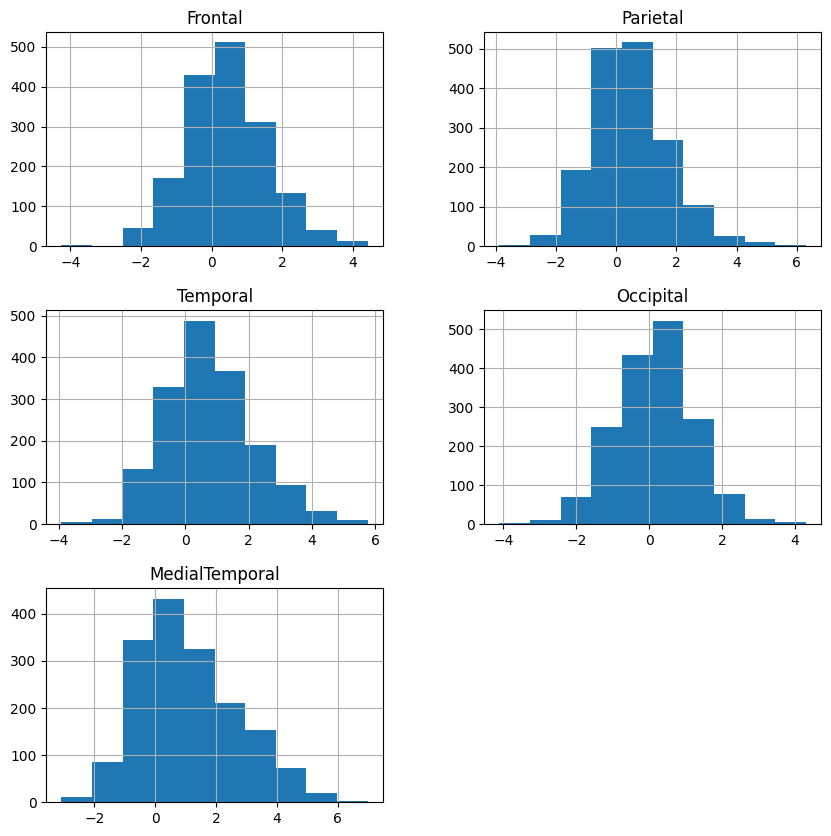

In [13]:
zdata[biomarkers].hist(figsize= (10,10))

# Prepare SuStaIn inputs

In [14]:
# The bulletproof, clean fix
mapping = {'male': 1, 'female': 0}

gender_status_array = data['PTGENDER'].str.lower().str.strip().map(mapping).to_numpy().astype(int)
print(gender_status_array)

[1 1 1 ... 0 1 1]


Now that we've z-scored our data, let's start prepping the many SuStaIn inputs

In [15]:
N = len(biomarkers)         # number of biomarkers

SuStaInLabels = biomarkers
Z_vals = np.array([[1,2,3]]*N)     # Z-scores for each biomarker
Z_max  = np.array([5]*N)           # maximum z-score
  

In [16]:
N_startpoints = 15
N_S_max = 2
N_iterations_MCMC = int(1e3)
#output_folder = os.path.join(os.getcwd(), 'MRI_Sustain_5features_all')
dataset_name = 'Cortical_atrophy_Sustain'
output_folder = os.path.join(os.getcwd(), model_type+subset_data)

use_agestage = False

In [17]:
sustain_input = ZscoreSustain_APOE4(zdata[biomarkers].values,
                                Z_vals,
                                Z_max,
                                SuStaInLabels,
                                N_startpoints,
                                N_S_max, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = apoe4_status,
                                #apoe4_status = gender_status_array,
                                apoe_flag = True)

1656 patients initially
 -> Detected 3 unique genetic categories: [0 1 2]
1656 patients with non null apoe4 carrier status
 -> [Genetics Setup] Global cohort background frequencies calculated: [0.54227053 0.36171498 0.09601449]
Running genetic weighted SuStaIn 


In [18]:


# Initiate the corrected SuStaIn object
# sustain_input = APOE4Sustain(
#     data=zdata[biomarkers].values,
#     Z_vals=Z_vals,
#     Z_max=Z_max,
#     biomarker_labels=SuStaInLabels,
#     N_startpoints=N_startpoints,
#     N_S_max=N_S_max, 
#     N_iterations_MCMC=N_iterations_MCMC, 
#     output_folder=output_folder, 
#     dataset_name=dataset_name, 
#     use_parallel_startpoints=False, 
#     apoe4_status=apoe4_status
# )

# Set the regularization parameter explicitly here
#sustain_input.lambda_reg = 0.01
                  

# Run SuStaIn!

In [19]:
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [20]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [21]:

ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()



Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/sustainall/pickle_files/Cortical_atrophy_Sustain_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1


MCMC Iteration: 100%|██████████| 1000/1000 [00:00<00:00, 1273.30it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.5423, Cat_1: 0.3617, Cat_2: 0.0960]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.5423, Cat_1: 0.3617, Cat_2: 0.0960]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/sustainall/pickle_files/Cortical_atrophy_Sustain_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 5 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using alternating me

MCMC Iteration: 100%|██████████| 1000/1000 [00:02<00:00, 461.73it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 46.63% of dataset
 -> Subtype 2 Cohort Size: 53.37% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.5423, Cat_1: 0.3617, Cat_2: 0.0960]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.3902, Cat_1: 0.4422, Cat_2: 0.1676]
 -> Subtype 2 Profile Prior : [Cat_0: 0.6743, Cat_1: 0.2918, Cat_2: 0.0339]



In [22]:
print(ml_sequence_EM.shape)

(2, 15, 1000)


# Evaluate subtypes

Here, we'll plot the log likelihood across MCMC samples, across each subtype. This will give us at least a basic sense of what how many subtypes we should consider looking at

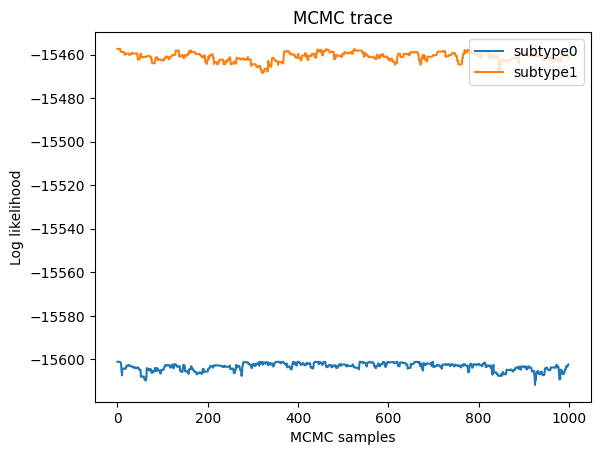

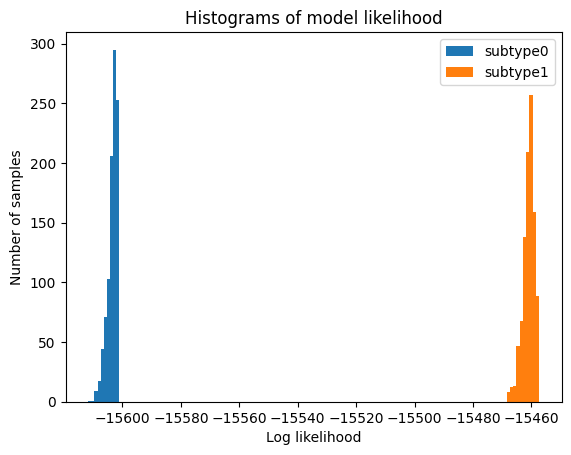

In [23]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="subtype" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="subtype" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


In [24]:
prob_subtype_stage.shape
prob_subtype_stage.sum(axis=1)

array([[0.71551639, 0.28448361],
       [0.03242484, 0.96757516],
       [0.49644802, 0.50355198],
       ...,
       [0.63820178, 0.36179822],
       [0.9029352 , 0.0970648 ],
       [0.05970257, 0.94029743]], shape=(1656, 2))

It is very clear from this output that two subtypes fits the data better than one subtype, but adding a third subtype does not improve the model fit significantly. Let's move forward with the 2 subtype model.

0
[1.]
[0]
1
[0.46632789 0.53367211]
[0 1]


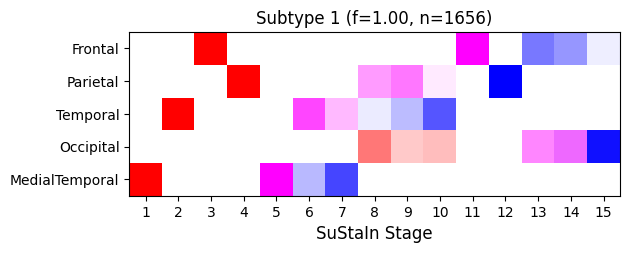

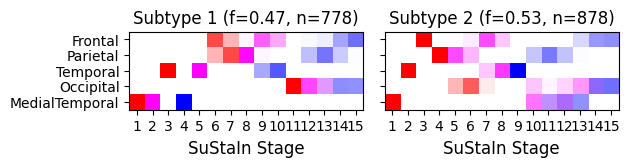

In [25]:
# Let's plot positional variance diagrams to interpret the subtype progressions
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(zdata) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=SuStaInLabels)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")

0
1


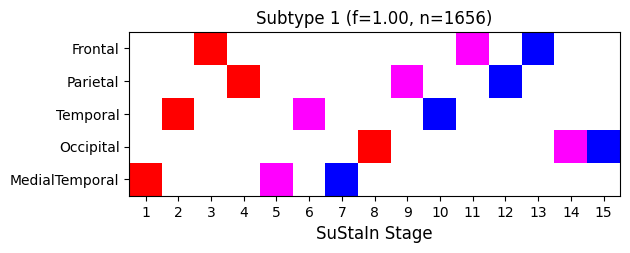

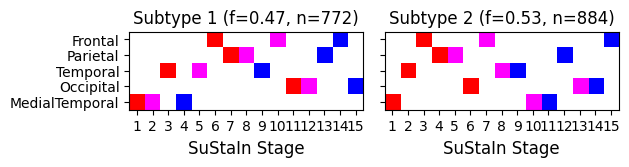

In [26]:
# Let's plot positional variance diagrams to interpret the subtype progressions
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(zdata) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    ml_f_EM = pk["ml_f_EM"]
    ml_sequence_EM = pk["ml_sequence_EM"]
    ml_sequence_EM =  np.expand_dims(ml_sequence_EM, axis=-1) 
    
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    ml_f_EM = np.expand_dims(ml_f_EM,axis=-1)
  
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,ml_sequence_EM,ml_f_EM,M,subtype_order=subtype_order,biomarker_labels=SuStaInLabels)
    plt.savefig(output_folder + f"/ML_Sequences{s}.png")

It seems we have one subtype where Biomarker 3 becomes severe quickly, and a second where Biomarker 3 becomes abnormal far later, while Biomarker 5 occurs earlier.

# Subtype and stage individuals

In [27]:
# let's take a look at all of the things that exist in SuStaIn's output (pickle) file
pk.keys()

dict_keys(['samples_sequence', 'samples_f', 'samples_likelihood', 'samples_genetic_weights', 'ml_subtype', 'prob_ml_subtype', 'ml_stage', 'prob_ml_stage', 'prob_subtype', 'prob_stage', 'prob_subtype_stage', 'ml_sequence_EM', 'ml_sequence_prev_EM', 'ml_f_EM', 'ml_f_prev_EM', 'ml_genetic_weights_EM', 'ml_genetic_weights_prev_EM'])

In [28]:


# The SuStaIn output has everything we need. We'll use it to populate our dataframe.

s = 1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)

for variable in ['ml_subtype', # the assigned subtype
                 'prob_ml_subtype', # the probability of the assigned subtype
                 'ml_stage', # the assigned stage 
                 'prob_ml_stage',]: # the probability of the assigned stage
    
    # add SuStaIn output to dataframe
    zdata.loc[:,variable] = pk[variable] 

# let's also add the probability for each subject of being each subtype
for i in range(s):
    zdata.loc[:,'prob_S%s'%i] = pk['prob_subtype'][:,i]
zdata.head()

,Unnamed: 0,RID,VISCODE,EXAMDATE,Years_bl,AGE,PTGENDER,PTEDUCAT,DX,MMSE,...,EcogSPTotal,Diagnosis,FS4,FS5,FS6,ml_subtype,prob_ml_subtype,ml_stage,prob_ml_stage,prob_S0
0,0,2,bl,08/09/2005,0.0,74.3,Male,16,CN,28.0,...,NaN,0.0,True,False,False,0.0,0.837149,1.0,0.171419,0.837149
1,1,3,bl,12/09/2005,0.0,81.3,Male,18,Dementia,20.0,...,NaN,2.0,True,False,False,1.0,0.977108,10.0,0.272496,0.022892
2,5,4,bl,08/11/2005,0.0,67.5,Male,10,MCI,27.0,...,NaN,1.0,True,False,False,0.0,0.668675,1.0,0.139435,0.668675
3,10,5,bl,07/09/2005,0.0,73.7,Male,16,CN,29.0,...,NaN,0.0,True,False,False,0.0,0.698841,0.0,0.210884,0.698841
4,15,6,bl,29/11/2005,0.0,80.4,Female,13,MCI,25.0,...,NaN,1.0,True,False,False,1.0,0.802510,2.0,0.293561,0.197490


In [29]:
zdata.ml_subtype.value_counts()

ml_subtype
0.0    975
1.0    681
Name: count, dtype: int64

In [30]:
# Make subtypes go from 1,2,..; add controls as another subtype and leave -1 as outliers
zdata.loc[zdata["ml_subtype"] != -1, "ml_subtype"] += 1
# zdata.loc[zdata.ml_stage==0,'ml_subtype'] = 0
# zdata.ml_subtype.value_counts()

In [31]:
zdata.ml_subtype.value_counts()

ml_subtype
1.0    975
2.0    681
Name: count, dtype: int64

In [32]:
zdata.loc[zdata.ml_stage==0,'ml_subtype'] = 0
zdata.ml_subtype.value_counts()

ml_subtype
0.0    752
2.0    458
1.0    446
Name: count, dtype: int64

In [33]:
zdata.to_csv(output_folder+'/subtype_and_stage_2subtypes.csv')

In [34]:
zdata.ml_subtype.value_counts()

ml_subtype
0.0    752
2.0    458
1.0    446
Name: count, dtype: int64

As a sanity check, let's make sure all the "controls" were given assigned to low stages by SuStaIn

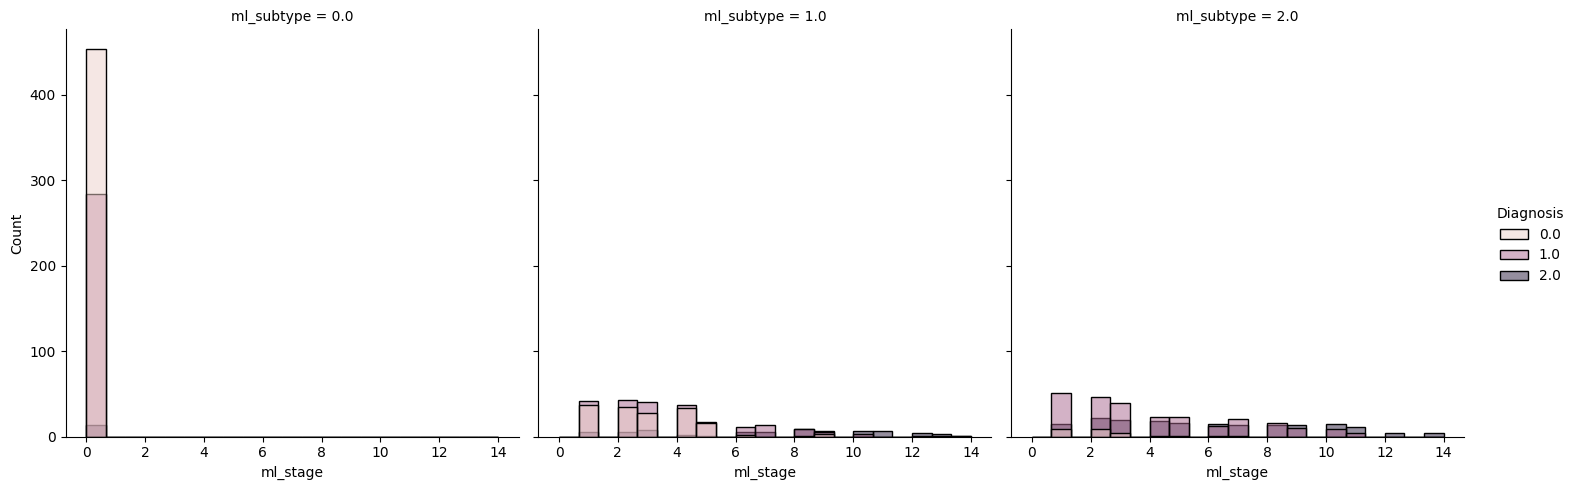

In [35]:
sns.displot(x='ml_stage',hue='Diagnosis',data=zdata,col='ml_subtype')
plt.savefig(output_folder+"/staging_per_subtype")

And now, let's plot the subtype probabilities over SuStaIn stages to make sure we don't have any crossover events

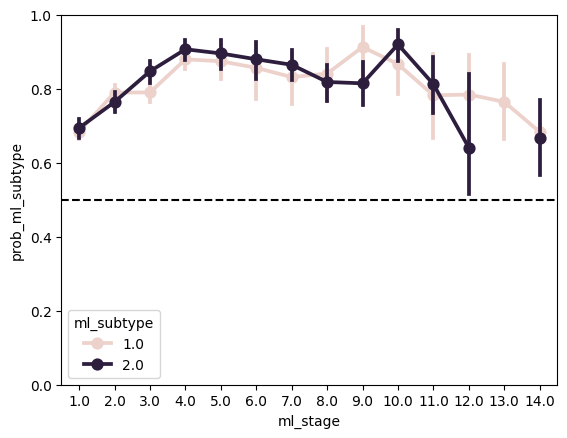

In [36]:
sns.pointplot(x='ml_stage',y='prob_ml_subtype', # input variables
              hue='ml_subtype',                 # "grouping" variable
            data=zdata[zdata.ml_subtype>0]) # only plot for Subtypes 1 and 2 (not 0)
plt.ylim(0,1) 
plt.axhline(0.5,ls='--',color='k') # plot a line representing change (0.5 in the case of 2 subtypes)

# Evaluate relationships

One might want to view whether there are relationships between SuStaIn subtype and stage and other variables.

This step should probably be done after you run cross-validation (see below), but we'll do it here first to keep up the momentum

In [37]:
biomarkers

['Frontal', 'Parietal', 'Temporal', 'Occipital', 'MedialTemporal']

[1. 2. 0.]


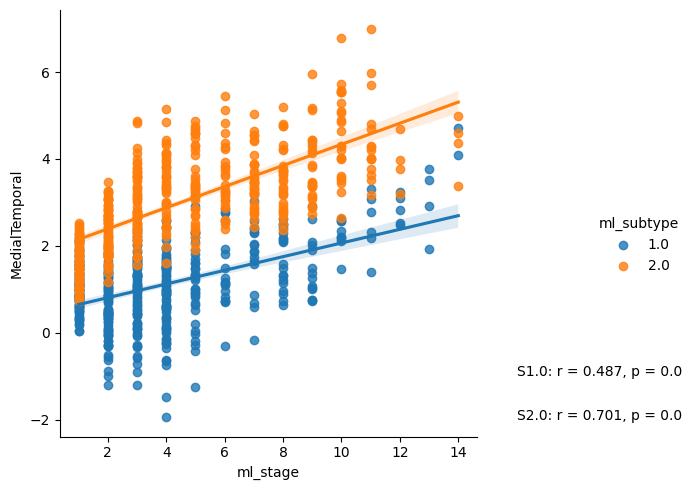

In [38]:
# Plotting relationship between a biomarker and SuStaIn stage across subtypes

var = 'MedialTemporal'

# plot relationship
sns.lmplot(x='ml_stage',y=var,hue='ml_subtype',
          data = zdata[zdata.ml_subtype>0],
           #lowess=True # uncomment if you would prefer a lowess curve to a linear curve
          )

subtypes = zdata.ml_subtype.unique()
print(subtypes)
subtypes = subtypes[subtypes>0]
# get stats
for subtype in subtypes:
    # get r and p value
    r,p = stats.pearsonr(x = zdata.loc[zdata.ml_subtype==subtype,var].values,
                         y = zdata.loc[zdata.ml_subtype==subtype,'ml_stage'].values)
    # add them to plot
    plt.text(16,0-subtype,'S%s: r = %s, p = %s'%(subtype,round(r,3),round(p,2)))

In [39]:
# we can also look at differences in each biomarker across subtypes
from scipy import stats

for s in subtypes:
    print('Subtype',s)
        
    results = pandas.DataFrame(index=biomarkers)
    for biomarker in biomarkers:
        t,p = stats.ttest_ind(zdata.loc[zdata.ml_subtype==0,biomarker],
                            zdata.loc[zdata.ml_subtype==s,biomarker],)
        results.loc[biomarker,'t'] = t
        results.loc[biomarker,'p'] = p
        
    print(results)

Subtype 1.0
                        t              p
Frontal        -30.498018  1.338711e-151
Parietal       -31.311552  1.121032e-157
Temporal       -34.650391  9.827565e-183
Occipital      -19.325536   1.245847e-72
MedialTemporal -24.506519  8.432019e-108
Subtype 2.0
                        t              p
Frontal        -19.115080   2.272756e-71
Parietal       -22.800721   5.396378e-96
Temporal       -34.159467  1.573293e-179
Occipital      -10.579818   4.446337e-25
MedialTemporal -57.191428   0.000000e+00


<Axes: >

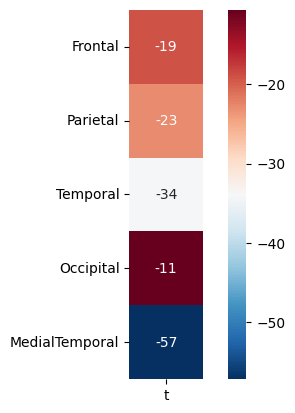

In [40]:
sns.heatmap(pandas.DataFrame(results['t']),square=True,annot=True,
           cmap='RdBu_r')

<Axes: xlabel='ml_subtype', ylabel='Frontal'>

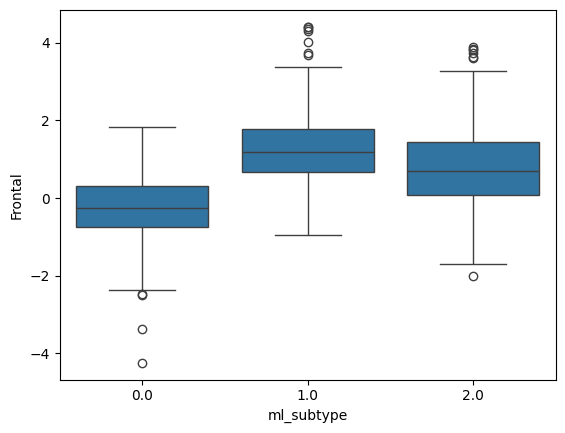

In [41]:
# plot an example variable:

var = 'Frontal'
sns.boxplot(x='ml_subtype',y=var,data=zdata)

In [42]:
prob_subtype = np.sum(prob_subtype_stage,axis=1)
prob_subtype.shape


(1656, 2)

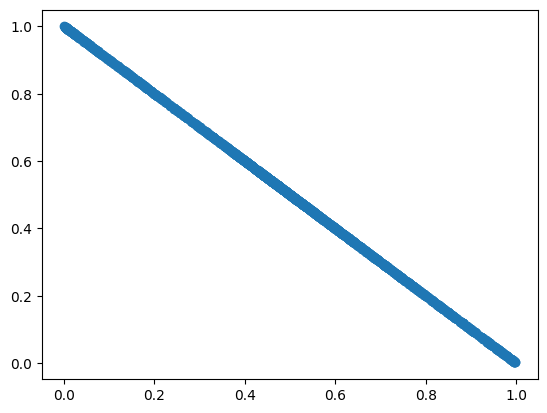

In [43]:
plt.scatter(prob_subtype[:,0],prob_subtype[:,1])

# Cross-validation

Finally, it is often difficult to decide how many subtypes best fit your data. This question should ideally be evaluated using cross-validation. This way, the likelihood metrics are generated for data that the model has not yet seen. 

FYI we may not have nough time to run this full cross-validation during the workshop, but it's good for you to run it yourself. SuStaIn also support parallelized cross-validation!

In [44]:
import pandas as pd

In [ ]:
# choose the number of folds - here i've used three for speed but i recommend 10 typically
N_folds = 3

# generate stratified cross-validation training and test set splits

labels = zdata.Diagnosis.values
cv = sklearn.model_selection.StratifiedKFold(n_splits=N_folds, shuffle=True)
cv_it = cv.split(zdata, labels)
#cv_it = cv.split(zdata, labels)

# SuStaIn currently accepts ragged arrays, which will raise problems in the future.
# We'll have to update this in the future, but this will have to do for now
test_idxs = []
for train, test in cv_it:
    test_idxs.append(test)
#test_idxs = np.array(test_idxs,dtype='object')
test_idxs = np.array(test_idxs)

In [48]:
test_idxs

array([[2, 3, 5, ..., 1649, 1651, 1652],
       [0, 1, 6, ..., 1650, 1653, 1655],
       [4, 8, 11, ..., 1641, 1647, 1654]], shape=(3, 552), dtype=object)

In [46]:
# perform cross-validation and output the cross-validation information criterion and
# log-likelihood on the test set for each subtypes model and fold combination
CVIC, loglike_matrix     = sustain_input.cross_validate_sustain_model(test_idxs)

Folds:   0%|          | 0/3 [00:00<?, ?it/s]


IndexError: arrays used as indices must be of integer (or boolean) type

# Choosing the optimal number of subtypes
The optimal number of subtypes is chosen using the CVIC, shown below. The CVIC is an information criterion (like the AIC/BIC/WAIC) that balances model complexity with model accuracy, with a lower CVIC indicating a better balance between the two. Generally speaking, the model with the lowest CVIC is the best. However, you do sometimes get a very small improvement (less than ~6) in the CVIC with a more complex model, in which case I would tend to favour the less complex (i.e. fewer subtypes) model.

Another useful metric to look at is the log-likelihood of each subtypes model on the test set, also shown below. A better model should show a consistent improvement in the test set log-likelihood across folds.

In [ ]:
# # go through each subtypes model and plot the log-likelihood on the test set and the CVIC
# print("CVIC for each subtype model: " + str(CVIC))
# print("Average test set log-likelihood for each subtype model: " + str(np.mean(loglike_matrix, 0)))

# plt.figure(0)    
# plt.plot(np.arange(N_S_max,dtype=int),CVIC)
# plt.xticks(np.arange(N_S_max,dtype=int))
# plt.ylabel('CVIC')  
# plt.xlabel('Subtypes model') 
# plt.title('CVIC')

# plt.figure(1)
# df_loglike = pandas.DataFrame(data = loglike_matrix, columns = ["s_" + str(i) for i in range(sustain_input.N_S_max)])
# df_loglike.boxplot(grid=False)
# plt.ylabel('Log likelihood')  
# plt.xlabel('Subtypes model') 
# plt.title('Test set log-likelihood across folds')

Another useful output of the cross-validation that you can look at are positional variance diagrams averaged across cross-validation folds. These give you an idea of the variability in the progression patterns across different training datasets.

In [ ]:
# #this part estimates cross-validated positional variance diagrams
# for i in range(N_S_max):
#     sustain_input.combine_cross_validated_sequences(i+1, N_folds)

In [ ]:
# N_S_selected = 2

# pySuStaIn.ZscoreSustain._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=(0,1))
# _ = plt.suptitle('SuStaIn output')

# sustain_input.combine_cross_validated_sequences(N_S_selected, N_folds)
# _ = plt.suptitle('Cross-validated SuStaIn output')

# Cognitive domain subtype associations

In [ ]:
data

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']

for feature in features:
    sns.histplot(data=data, x=feature, hue='ml_subtype', multiple='stack')
    plt.title(f'Histogram of {feature} by ml_subtype')
    plt.show()


In [ ]:
# plot 
#for cog_domain in ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']:
    #print('Std err',data.groupby('ml_subtype')[cog_domain].std())
    #print('Mean',data.groupby('ml_subtype')[cog_domain].mean())
# same thing in a much cleaner way:
domains = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']
summary = data.groupby("ml_subtype")[domains].agg(["mean", "std"])
print(summary)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
x = range(len(domains))

for subtype in summary.index:
    means = summary.loc[subtype, (slice(None), "mean")].values
    stds  = summary.loc[subtype, (slice(None), "std")].values
    
    ax.plot(x, means, marker="o", label=f"Subtype {subtype}")
    ax.fill_between(x, means-stds, means+stds, alpha=0.2)

ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=30)
ax.set_ylabel("Score")
ax.set_title("Mean ± SD cognitive profiles across subtypes")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

features = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']
subtypes = [0,1,2]

# Compute mean values per subtype
mean_matrix = data.groupby('ml_subtype')[features].mean()

# Compute ANOVA p-values per feature
p_values = []
for f in features:
    groups = [data[data['ml_subtype']==s][f] for s in subtypes]
    _, p_val = f_oneway(*groups)
    p_values.append(p_val)

# Convert p-values to significance stars
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

stars = [p_to_stars(p) for p in p_values]

# Plot heatmap of mean values
plt.figure(figsize=(8, 5))
ax = sns.heatmap(mean_matrix, annot=True, fmt=".2f", cmap="vlag",
                 linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean Value'})

# Update column labels to include significance stars
new_labels = [f"{col} {stars[i]}" for i, col in enumerate(mean_matrix.columns)]
ax.set_xticklabels(new_labels, rotation=45, ha='right')

plt.title("Mean Feature Values by ml_subtype with ANOVA Significance", fontsize=14)
plt.ylabel("ml_subtype", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

features = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']
subtypes_to_compare = [1,2]

# Filter the data to only the two subtypes
data_subtypes = data[data['ml_subtype'].isin(subtypes_to_compare)]

# Compute mean values per subtype
mean_matrix = data_subtypes.groupby('ml_subtype')[features].mean()

# Compute t-test p-values between subtype 1 and subtype 2
p_values = []
for f in features:
    group1 = data_subtypes[data_subtypes['ml_subtype']==subtypes_to_compare[0]][f]
    group2 = data_subtypes[data_subtypes['ml_subtype']==subtypes_to_compare[1]][f]
    _, p_val = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
    p_values.append(p_val)


# Convert p-values to significance stars
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

stars = [p_to_stars(p) for p in p_values]

# Plot heatmap
plt.figure(figsize=(6, 5))
ax = sns.heatmap(mean_matrix, annot=True, fmt=".2f", cmap="vlag",
                 linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean Value'})

# Update column labels to include stars for t-test between subtypes
new_labels = [f"{col} {stars[i]}" for i, col in enumerate(mean_matrix.columns)]
ax.set_xticklabels(new_labels, rotation=45, ha='right')

plt.title("Mean Feature Values: Subtype 1 vs Subtype 2 Significance", fontsize=14)
plt.ylabel("ml_subtype", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.show()


# Subtype and stage associations



In [ ]:
# linear regression to see how much subtype and stage assoc with memory
# 
import statsmodels.formula.api as smf

# Suppose df has 'cognitive_domain', 'ml_subtype', 'stage'
data_patients = data[data['ml_subtype']>0]
model = smf.ols("PHC_MEM ~ ml_subtype * ml_stage+ AGE ", data=data_patients).fit()
print(model.summary())


In [ ]:
# encode subtype as categorical
import pandas as pd
import statsmodels.formula.api as smf

data_patients = data[data['ml_subtype']>0]
# Ensure subtype is categorical, with 1 as reference
data_patients['ml_subtype'] = data_patients['ml_subtype'].astype('category')
data_patients['ml_subtype'] = data_patients['ml_subtype'].cat.reorder_categories([1, 2], ordered=True)

# Fit linear regression
model = smf.ols("PHC_MEM ~ ml_subtype +ml_stage", data=data_patients).fit()

# Print summary
print(model.summary())


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Filter out controls (assuming 0 = control)
data_patients = data[data['ml_subtype'] > 0].copy()

# Ensure subtype is categorical with 1 as reference
data_patients['ml_subtype'] = data_patients['ml_subtype'].astype('category')
data_patients['ml_subtype'] = data_patients['ml_subtype'].cat.reorder_categories([1, 2], ordered=True)

# List of cognitive domains
cognitive_domains = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']  # replace with your actual column names

# Function to convert p-value to significance stars
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Store results
results = []

for domain in cognitive_domains:
    formula = f"{domain} ~ ml_subtype * ml_stage + AGE"
    model = smf.ols(formula, data=data_patients).fit()
    
    coef = model.params.get('ml_subtype[T.2]', float('nan'))
    pval = model.pvalues.get('ml_subtype[T.2]', float('nan'))
    star = p_to_stars(pval)
    
    results.append({
        'Cognitive Domain': domain,
        'Subtype 2 vs 1 coef': coef,
        'p-value': pval,
        'Significance': star
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Filter out controls
data_patients = data[data['ml_subtype'] > 0].copy()

# Ensure subtype is categorical with 1 as reference
data_patients['ml_subtype'] = data_patients['ml_subtype'].astype('category')
data_patients['ml_subtype'] = data_patients['ml_subtype'].cat.reorder_categories([1, 2], ordered=True)

# List of cognitive domains
cognitive_domains = ['PHC_MEM','PHC_EXF','PHC_LAN','PHC_VSP']  

# Function to convert p-value to significance stars
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Store results
results = []

for domain in cognitive_domains:
    formula = f"{domain} ~ ml_subtype * ml_stage + AGE"
    model = smf.ols(formula, data=data_patients).fit()
    
    # Extract coefficients and p-values
    subtype_coef = model.params.get('ml_subtype[T.2]', float('nan'))
    subtype_pval = model.pvalues.get('ml_subtype[T.2]', float('nan'))
    
    stage_coef = model.params.get('ml_stage', float('nan'))
    stage_pval = model.pvalues.get('ml_stage', float('nan'))
    
    interaction_coef = model.params.get('ml_subtype[T.2]:ml_stage', float('nan'))
    interaction_pval = model.pvalues.get('ml_subtype[T.2]:ml_stage', float('nan'))
    
    results.append({
        'Cognitive Domain': domain,
        'Subtype 2 vs 1 coef': subtype_coef,
        'Subtype 2 vs 1 p-value': subtype_pval,
        'Subtype 2 vs 1 significance': p_to_stars(subtype_pval),
        'Stage coef': stage_coef,
        'Stage p-value': stage_pval,
        'Stage significance': p_to_stars(stage_pval),
        'Subtype:Stage interaction coef': interaction_coef,
        'Interaction p-value': interaction_pval,
        'Interaction significance': p_to_stars(interaction_pval)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


Subtype 2 slighly worse than subtype 1 in terms of memory; but within subtype variability is large. This is bc cognitive domains vary with stage;

# Subtype and stage longitudinal data 

In [ ]:
data_longitudinal = pandas.read_csv('/Users/mihaelacroitor/project/data/clinical_data/atrophy_data/processed_data/longitudinal_data_5ROI.csv')
data_longitudinal

In [ ]:
ml_subtype, prob_ml_subtype, ml_stage, prob_ml_stage, prob_subtype, prob_stage, prob_subtype_stage = sustain_input.subtype_and_stage_individuals_newData(data_longitudinal[biomarkers].values, samples_sequence=samples_sequence,samples_f=samples_f, N_samples=1000)

In [ ]:
ml_subtype

In [ ]:
prob_stage.shape

In [ ]:
data_longitudinal['ml_subtype'] = ml_subtype
data_longitudinal['ml_stage'] = ml_stage
data_longitudinal['prob_ml_subtype'] = prob_ml_subtype
data_longitudinal['prob_ml_stage'] = prob_ml_stage
# 
data_longitudinal.loc[data_longitudinal["ml_subtype"] != -1, "ml_subtype"] += 1
data_longitudinal.loc[data_longitudinal.ml_stage==0,'ml_subtype'] = 0

In [ ]:
data_longitudinal

# Cox proportional hazards ratio 
event: binary indicator (1 = MCI→Dementia conversion, 0 = censored).
If a participant starts with MCI and later has a diagnosis of Dementia, then event = 1 and time = time of that dementia visit.

If a participant never converts to Dementia (remains MCI or reverts/stays stable until last follow-up), then event = 0 and time = last available follow-up time.

In [ ]:
# STEP 1 filter data: only MCI at baseline
baseline = data_longitudinal[data_longitudinal['VISCODE'] == 'bl']
# baseline with MCI diagnosis
MCI_baseline = baseline[baseline['DX']=='MCI']
# unique ID of patients with MCI at baseline
RID_MCI_baseline = MCI_baseline.RID.values
# select all datapoints of patients with MCI at baseline
mask = data_longitudinal['RID'].isin(RID_MCI_baseline)
MCI_bl_data = data_longitudinal[mask]

In [ ]:
# STEP 2: Time to event variable
# for converters (people that were MCI at bl and turned Dementia), choose only 1st appointment with Dementia diagnosis; discard rest
converters = MCI_bl_data[MCI_bl_data['DX'] == 'Dementia']
print(len(converters))
# Dementia visits

# Sort by subject and time
dementia_sorted = converters.sort_values(["RID", "Years_bl"])

# First conversion per subject
first_conversion = (
    dementia_sorted.groupby("RID")
    .first()
    .reset_index()[["RID", "Years_bl","ml_subtype","ml_stage"]]
    .rename(columns={"Years_bl": "time_to_event"})
)
first_conversion["event"] = 1
print(first_conversion)

In [ ]:
# for non converters (people that stay MCI or revert to CN) choose only last follow up appointment and censor them (event=0)
non_converters = MCI_bl_data[MCI_bl_data['DX'] != 'Dementia']
last_visit = (non_converters.groupby('RID', as_index=False)[['Years_bl','ml_subtype','ml_stage']]
              .max().rename(columns={'Years_bl': 'time_to_event'}))
last_visit['event'] = 0
last_visit

In [ ]:

# --- 5) merge converters and non-converters: prefer conversion time when present ---
surv = last_visit.merge(first_conversion, on='RID', how='left', suffixes=('_last', '_conv'))

# use conversion time where available, otherwise last visit time
surv['time_to_event'] = surv['time_to_event_conv'].fillna(surv['time_to_event_last'])


surv['ml_subtype_app'] = surv['ml_subtype_conv'].fillna(surv['ml_subtype_last'])
surv['ml_stage_app'] = surv['ml_stage_conv'].fillna(surv['ml_stage_last'])
# event = 1 if conversion exists, otherwise 0
surv['event'] = surv['event_conv'].fillna(0).astype(int)

surv = surv[['RID', 'time_to_event', 'event','ml_subtype_app','ml_stage_app']]
surv

In [ ]:

# --- 6) attach baseline covariates (from baseline MCI row) ---
baseline_covs = MCI_baseline.set_index('RID')[['ml_subtype','ml_stage','AGE', 'PTGENDER', 'PTEDUCAT']]  # add any covariates you need
cox_df = surv.set_index('RID').join(baseline_covs).reset_index()

# --- 7) small cleanups (optional) ---
# convert gender to binary (example)
cox_df['sex_male'] = cox_df['PTGENDER'].str.lower().map({'male': 1, 'female': 0})
cox_df = cox_df.drop(columns=['PTGENDER','ml_subtype_app','ml_stage_app'])
# remove non-positive times if these exist due to bad dates
cox_df = cox_df[cox_df['time_to_event'] > 0].copy()
# final cox-ready dataframe
#print(cox_df)


In [ ]:
# cox_df = cox_df[cox_df['ml_subtype'] >0]
# cox_df

In [ ]:
# whats up with the diff models in the paper (with diff order and number of subtypes)
# do i just use my 2 subtypes? should i remove subjects assigned stage 0?


In [ ]:
# Install lifelines if you don't already have it:
# pip install lifelines

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter

# Fit Cox Proportional Hazards model
cox_data = cox_df.drop(columns = 'RID').copy()
cox_data = cox_data[cox_data['ml_subtype'] >0].copy()
# model with subtype 1, 2 no controls
cph = CoxPHFitter()
cph.fit(cox_data, duration_col="time_to_event", event_col="event")

# Show summary
print(cph.summary)

# Predict hazard ratios
print("\nHazard ratios:")
print(np.exp(cph.params_))


In [ ]:
# Cox model for controls, 1,2,
# Install lifelines if you don't already have it:
# pip install lifelines

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter

# Fit Cox Proportional Hazards model
cox_data = cox_df.drop(columns = 'RID').copy()
# model with subtype 1, 2 no controls
cph = CoxPHFitter()
cph.fit(cox_data, duration_col="time_to_event", event_col="event")

# Show summary
print(cph.summary)

# Predict hazard ratios
print("\nHazard ratios:")
print(np.exp(cph.params_))


In [ ]:
import matplotlib.pyplot as plt

# 1. Baseline survival curve (using mean covariates = all zeros if none)
baseline_surv = cph.predict_survival_function(cox_data.mean().to_frame().T)

plt.figure(figsize=(8,5))
plt.step(baseline_surv.index, baseline_surv.values.flatten(), where="post")
plt.title('Baseline Survival Curve')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.show()

# 2. Survival curves for first 3 subjects
plt.figure(figsize=(8,5))
for i in range(3):
    surv_func = cph.predict_survival_function(cox_data.iloc[[i]])
    plt.step(surv_func.index, surv_func.values.flatten(), where="post", label=f'Subject {i+1}')
plt.title('Predicted Survival Curves for Selected Subjects')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

# 3. By subtype (if 'subtype' exists)
if 'subtype' in cox_data.columns:
    plt.figure(figsize=(8,5))
    for stype in cox_data['subtype'].unique():
        subset = cox_data[cox_data['subtype']==stype]
        mean_covariates = subset.mean().to_frame().T
        surv_func = cph.predict_survival_function(mean_covariates)
        plt.step(surv_func.index, surv_func.values.flatten(), where="post", label=f'Subtype {stype}')
    plt.title('Predicted Survival Curves by Subtype')
    plt.xlabel('Time')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Loop over subtypes
for stype in [0, 1, 2]:
    subset = cox_data[cox_data['ml_subtype'] == stype]
    mean_covariates = subset.mean().to_frame().T  # make it DataFrame
    surv_func = cph.predict_survival_function(mean_covariates)
    plt.step(surv_func.index, surv_func.values.flatten(), where="post", label=f'Subtype {stype}')

plt.title('Predicted Survival Curves by Subtype')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()


In [ ]:
data_longitudinal.columns

# Longitudinal Consistency

I guess group data by patient RID, then present it like this; patient subtype at baseline, and at all next appointments
Also look into patient staging, it should only increase not reverse;


How would I plot this in a way that makes sense;
maybe number would be better, easier to compare with sustain+outlier model


## Subtype consistency

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

# Baseline data
bl = data_longitudinal[data_longitudinal['VISCODE'] == 'bl'][['ml_subtype', 'RID']]

# All follow-up timepoints (excluding baseline)
#timepoints = [tp for tp in data_longitudinal['VISCODE'].unique() if tp != 'bl']
timepoints = ['m06', 'm12', 'm24', 'm18', 'm36', 'm48', 'm60']

# Store balanced accuracy results
results = []

for time in timepoints:
    followup = data_longitudinal[data_longitudinal['VISCODE'] == time][['ml_subtype','RID']]
    
    # Merge with baseline by RID
    subtype_agreement = pd.merge(bl, followup, on='RID')
    
    if subtype_agreement.empty:
        continue  # skip if no matching subjects
    
    # Balanced accuracy
    bal_acc = balanced_accuracy_score(
        subtype_agreement['ml_subtype_x'], 
        subtype_agreement['ml_subtype_y']
    )
    
    results.append({"timepoint": time, "balanced_accuracy": bal_acc})
    
    # Confusion matrix
    cm = confusion_matrix(subtype_agreement['ml_subtype_x'], subtype_agreement['ml_subtype_y'])
    display = ConfusionMatrixDisplay(cm, display_labels=[0, 1, 2])
    display.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix: Baseline vs {time}")
    plt.ylabel("Subtype at baseline", fontsize=10)
    plt.xlabel(f"Subtype at follow-up: {time}", fontsize=10)
    plt.show()

# Summary dataframe
df_results = pd.DataFrame(results)
print(df_results)

# Optional: plot balanced accuracy over time
plt.figure(figsize=(6,4))
plt.plot(df_results['timepoint'], df_results['balanced_accuracy'], marker='o')
plt.xlabel("Timepoint")
plt.ylabel("Balanced Accuracy")
plt.title("Longitudinal Subtype Consistency (Balanced Accuracy)")
plt.ylim(0,1)
plt.grid(True)
plt.show()


# at 12 months

In [ ]:
bl = data_longitudinal[data_longitudinal['VISCODE'] == 'bl'][['ml_subtype','RID']]
time = 'm12'
followup = data_longitudinal[data_longitudinal['VISCODE'] == time][['ml_subtype','RID']]
subtype_agreement = pd.merge(bl,followup,on='RID')

from sklearn.metrics import classification_report

report = classification_report(subtype_agreement['ml_subtype_x'], subtype_agreement['ml_subtype_y'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)  # don't know which metrics to save
print(f"Longitudinal consistency accuracy at {time} post baseline",report["accuracy"])
consistency12 = np.round(report["accuracy"],2)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(subtype_agreement['ml_subtype_x'],subtype_agreement['ml_subtype_y'])
display = ConfusionMatrixDisplay(cm,display_labels=[0,1,2])
display.plot(cmap=plt.cm.Blues) 
plt.ylabel('Subtype at baseline', fontsize=10, color='black')
plt.xlabel(f"Subtype at follow-up: {time} ", fontsize=10, color='black')
plt.show()


Analyse those who switched subtypes

In [ ]:
switchers = subtype_agreement[ subtype_agreement['ml_subtype_x'] != subtype_agreement['ml_subtype_y'] ]
print('Subjects who changed subtype ',len(switchers),'out of',len(subtype_agreement))
print(len(subtype_agreement) - len(switchers))
stable    = subtype_agreement[ subtype_agreement['ml_subtype_x'] == subtype_agreement['ml_subtype_y'] ]

In [ ]:
bl = data_longitudinal[data_longitudinal['VISCODE'] == 'bl'][['ml_subtype','RID','prob_ml_subtype']]
time = 'm24'
followup = data_longitudinal[data_longitudinal['VISCODE'] == time][['ml_subtype','RID','prob_ml_subtype']]
subtype_agreement = pd.merge(bl,followup,on='RID')

from sklearn.metrics import classification_report

report = classification_report(subtype_agreement['ml_subtype_x'], subtype_agreement['ml_subtype_y'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)  # don't know which metrics to save
print(f"Longitudinal consistency accuracy at {time} post baseline",report["accuracy"])
consistency24 = np.round(report["accuracy"],2)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(subtype_agreement['ml_subtype_x'],subtype_agreement['ml_subtype_y'])
display = ConfusionMatrixDisplay(cm,display_labels=[0,1,2])
display.plot(cmap=plt.cm.Blues) 
plt.ylabel('Subtype at baseline', fontsize=10, color='black')
plt.xlabel(f"Subtype at follow-up: {time} ", fontsize=10, color='black')
plt.show()


In [ ]:
switchers = subtype_agreement[ subtype_agreement['ml_subtype_x'] != subtype_agreement['ml_subtype_y'] ]
print('Subjects who changed subtype ',len(switchers),'out of',len(subtype_agreement))
stable    = subtype_agreement[ subtype_agreement['ml_subtype_x'] == subtype_agreement['ml_subtype_y'] ]

In [ ]:
plt.figure()
stable.prob_ml_subtype_x.hist(label = 'stable bl')
stable.prob_ml_subtype_y.hist(label = 'stable m24')
switchers.prob_ml_subtype_x.hist(label='switchers bl')
switchers.prob_ml_subtype_y.hist(label = 'switchers m24')
plt.legend()
plt.title('Subtype probabilities at bl and follow up of stable patients and subtype switchers')
plt.show()


# Staging consistency

# Clinical outcome prediction based on stage
MCI converters to Dementia

In [ ]:
import pandas as pd
import numpy as np

# 1️ Select baseline MCI patients
mci_baseline = data[data['DX'] == 'MCI'][['RID', 'DX','ml_subtype','ml_stage']].copy()

# 2️ Pivot longitudinal data: each patient = row, columns = VISCODE
pivoted = data_longitudinal.pivot(index='RID', columns='VISCODE', values='DX')

# 3️ Keep only baseline MCI patients
pivoted = pivoted.loc[mci_baseline['RID']]

# Sort columns in chronological order if needed (important!)
pivoted = pivoted.reindex(sorted(pivoted.columns), axis=1)

# 4️ Create conversion columns with forward fill logic
converted_flag = np.zeros(len(pivoted), dtype=bool)  # track if converted before

for col in pivoted.columns:
    if col == 'bl':
        continue  # skip baseline
    
    # check who has converted at this visit
    converted_now = (pivoted[col] == 'Dementia')
    converted_flag = converted_flag | converted_now.fillna(False)  # update conversion status

    # assign 1 if converted now or before
    mci_baseline[f'MCI_converter_{col}'] = np.where(
        converted_flag,  # converted previously or now
        1,
        np.where(pivoted[col].isna(), np.nan, 0)  # if missing and never converted, keep NaN
    )

print(mci_baseline.head())


In [ ]:
# choose optimum threshold for conversion prediction
from sklearn.metrics import accuracy_score
cols = [col  for col in mci_baseline.columns if 'converter' in col]
stages = np.unique(ml_stage)
plt.figure(figsize=(10,5))
for col in cols:
    metrics_acc = []
    for t in stages:
        mci_baseline.loc[ mci_baseline['ml_stage']>=t,'pred'] = 1
        mci_baseline.loc[ mci_baseline['ml_stage']<t,'pred'] = 0
        mask = mci_baseline[col].isna()
        df = mci_baseline[~mask]
        acc = accuracy_score(df[col],df['pred'])
        
        metrics_acc.append(acc)

    plt.scatter(stages,metrics_acc,label = col)
    plt.plot(stages,metrics_acc)
plt.title('Acc for MCI converter prediction based on stage threshold')
plt.ylabel('MCI converter balanced acc')
plt.xlabel('Stage threshold')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,confusion_matrix

# identify all converter columns
cols = [col for col in mci_baseline.columns if 'converter' in col]
stages = np.unique(mci_baseline['ml_stage'])

plt.figure(figsize=(10,5))

# dictionary to store optimal thresholds and metrics
opt_metrics = {}

for col in cols:
    metrics_acc = []
    metrics_sens = []
    metrics_spec = []
    
    mask = mci_baseline[col].notna() & mci_baseline['ml_stage'].notna()
    df = mci_baseline.loc[mask].copy()
    
   
    for t in stages:
        df['pred'] = (df['ml_stage'] >= t).astype(int)
        
        # compute confusion matrix safely
        cm = confusion_matrix(df[col], df['pred'], labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        bal_acc = (sensitivity + specificity) / 2
        #bal_acc = balanced_accuracy_score(df[col], df['pred'])
        
        metrics_acc.append(bal_acc)
        metrics_sens.append(sensitivity)
        metrics_spec.append(specificity)

    
    # find optimal threshold (max balanced accuracy)
    opt_idx = np.argmax(metrics_acc)
    opt_threshold = stages[opt_idx]
    opt_metrics[col] = {
        'threshold': opt_threshold,
        'balanced_acc': metrics_acc[opt_idx],
        'sensitivity': metrics_sens[opt_idx],
        'specificity': metrics_spec[opt_idx]
    }
    
    # plot balanced accuracy curve
    plt.plot(stages, metrics_acc, marker='o', label=f"{col} (opt t={opt_threshold})")

plt.title('Balanced accuracy vs stage threshold')
plt.xlabel('Disease stage threshold')
plt.ylabel('Balanced accuracy')
plt.legend()
plt.grid(True)
plt.show()

# show optimal thresholds and metrics
for col, metrics in opt_metrics.items():
    print(f"{col}: threshold={metrics['threshold']}, "
          f"balanced_acc={metrics['balanced_acc']:.3f}, "
          f"sensitivity={metrics['sensitivity']:.3f}, "
          f"specificity={metrics['specificity']:.3f}")


In [ ]:
# AUC score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

for col in cols:
    # select rows with non-missing stage and label
    mask = mci_baseline['ml_stage'].notna() & mci_baseline[col].notna()
    y_true = mci_baseline.loc[mask, col].astype(int).values   # your true labels
    y_score = mci_baseline.loc[mask, 'ml_stage'].astype(float).values  # stage as score


    if len(set(y_true)) < 2:
        print(f"Column {col}: only one class present, skipping AUC/ROC.")
        continue

    # ROC AUC
    auc = roc_auc_score(y_true, y_score)
    print(f"Column {col} - ROC AUC: {auc:.3f}")

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    #plt.figure(figsize=(6,6))
    label = col.split("_")[-1]
    plt.plot(fpr, tpr, marker='o', label=f'{label} (AUC = {auc:.3f})')
    plt.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Roc Curve AUC score ")# {col}")
    plt.legend()
    plt.grid(True)
plt.show()


In [ ]:
# One table containing all metrics

# MCI to Dementia conversion based on both subtype and stage

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Identify the conversion columns
timepoint_cols = [col for col in mci_baseline.columns if col.startswith('MCI_converter_')]
print(timepoint_cols)
results = []

for tp_col in timepoint_cols:
    df_tp = mci_baseline[['ml_subtype', 'ml_stage', tp_col]].dropna()  # drop missing follow-ups
    if df_tp.shape[0] == 0:
        print(f"Skipping {tp_col}: no data available")
        continue
    # Fit logistic regression
    model = smf.logit(f"{tp_col} ~ ml_subtype + ml_stage", data=df_tp).fit(disp=0)
    
    # Predictions
    df_tp['pred_prob'] = model.predict(df_tp)
    df_tp['pred_class'] = (df_tp['pred_prob'] >= 0.5).astype(int)
    
    # Metrics
    accuracy = accuracy_score(df_tp[tp_col], df_tp['pred_class'])
    cm = confusion_matrix(df_tp[tp_col], df_tp['pred_class'])
    print(cm)
    
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
    else:
        sensitivity = specificity = float('nan')  # if only one class present
    
    #auc = roc_auc_score(df_tp[tp_col], df_tp['pred_prob'])
    
    results.append({
        'timepoint': tp_col,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        #'AUC': auc
    })

results_df = pd.DataFrame(results)
print(results_df)
